## Yellow-legged hornet model

**11 - Patch construction**

12 - Grid Search

13 - PSO

14 - Simulation

15 - Map

Spatial Division 1

 Region 1: France

 Region 2: others

**Spatial Division 2**

 Region 1: France _+ Portugal

 Region 2: others


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import os
import zipfile
import warnings

### Import data

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/MSC_PROJECT_YJ/data/Vespa_velutina_nigrithorax_all.csv')

In [ ]:
# !pwd

In [ ]:
# df = pd.read_csv("data/Pueraria_montana.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4407 entries, 0 to 4406
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ObservationId        4407 non-null   object 
 1   SpeciesId            4407 non-null   object 
 2   SpeciesName          4407 non-null   object 
 3   CountryId            4407 non-null   object 
 4   WKT                  4407 non-null   object 
 5   Centroid             4407 non-null   bool   
 6   Year                 4407 non-null   int64  
 7   DataPartnerName      4407 non-null   object 
 8   Reference            4407 non-null   object 
 9   ReferenceUrl         4406 non-null   object 
 10  GeoJSON.type         4382 non-null   object 
 11  GeoJSON.coordinates  4382 non-null   object 
 12  Longitude            4382 non-null   float64
 13  Latitude             4382 non-null   float64
dtypes: bool(1), float64(2), int64(1), object(10)
memory usage: 452.0+ KB


In [ ]:
df.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON.type,GeoJSON.coordinates,Longitude,Latitude
0,1304785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT(8.205464695992521 49.59117445055347),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.20546, 49.5912]",8.20546,49.5912
1,1804785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,GEOMETRYCOLLECTION(POINT(8.875633317136042 49....,True,2024,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
2,1B04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,UK,"POLYGON ((-2.30719327926636 53.6162755726417, ...",True,2018,NOTSYS,UK - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
3,2004785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,NL,POINT (5.95733642578125 50.9165628178882),False,2020,NOTSYS,NL - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[5.95734, 50.9166]",5.95734,50.9166
4,2704785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.12185156818582 49.5164901827448),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.12185, 49.5165]",6.12185,49.5165


In [ ]:
len(df)

4407

In [ ]:
df["Centroid"].value_counts(dropna=False)

,count
Centroid,
True,3826
False,581


In [ ]:
df["WKT"].str.extract(r"^(\w+)")[0].value_counts()

,count
0,
POINT,4382
GEOMETRYCOLLECTION,18
POLYGON,6
MULTIPOINT,1


In [ ]:
df.groupby(
    ["Centroid", "GeoJSON.type"]
).size()


,,0
Centroid,GeoJSON.type,
False,Point,581
True,Point,3801


In [ ]:
df["Year"].value_counts().sort_index()

,count
Year,
2010,10
2011,1
2012,1
2013,14
2014,15
2015,110
2016,2275
2017,16
2018,1721


In [ ]:
print(df.groupby(["CountryId", "Year"]).size().reset_index().to_string(index=False))

CountryId  Year    0
       AT  2024    1
       BE  2011    1
       BE  2016    6
       BE  2017    5
       BE  2018  110
       BE  2019    6
       BE  2020   59
       BE  2022    4
       CZ  2023    1
       CZ  2024    1
       DE  2017    1
       DE  2018   13
       DE  2019    3
       DE  2020    4
       DE  2021    5
       DE  2022   11
       DE  2023   11
       DE  2024   12
       DE  2025    1
       DK  2025    1
       ES  2010   10
       ES  2013    1
       ES  2016  392
       ES  2017    1
       ES  2018  817
       ES  2019   12
       ES  2020    9
       ES  2021    1
       ES  2022    1
       FR  2012    1
       FR  2014    1
       FR  2016 1652
       FR  2017    6
       FR  2018  743
       FR  2019    1
       FR  2020    1
       FR  2021    2
       FR  2022    3
       HU  2023    1
       IE  2021    1
       IE  2025    3
       IT  2013    2
       IT  2014   14
       IT  2015  110
       IT  2016  198
       IT  2018   32
       IT  20

In [ ]:
# df[df.Centroid == False ].groupby(
#     ["DataPartnerName", "Year","Centroid"]
# ).size().reset_index()

df.groupby(["DataPartnerName", "Year","Centroid"]).size().reset_index()

,DataPartnerName,Year,Centroid,0
0,BE-CA,2016,False,1
1,EASIN-Lit,2010,True,10
2,EASIN-Lit,2013,True,12
3,EU BASELINE,2016,True,2097
4,EU REPORTS,2018,True,1682
5,GBIF,2011,False,1
6,GBIF,2012,False,1
7,GBIF,2014,False,1
8,GBIF,2016,False,3
9,GBIF,2017,False,8


### Cleaning data--drop NA

In [ ]:
print(df.columns.tolist())

['ObservationId', 'SpeciesId', 'SpeciesName', 'CountryId', 'WKT', 'Centroid', 'Year', 'DataPartnerName', 'Reference', 'ReferenceUrl', 'GeoJSON.type', 'GeoJSON.coordinates', 'Longitude', 'Latitude']


In [ ]:
df.isna().sum()
df[df.Longitude.isna() | df.Latitude.isna()]

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON.type,GeoJSON.coordinates,Longitude,Latitude
1,1804785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,GEOMETRYCOLLECTION(POINT(8.875633317136042 49....,True,2024,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
2,1B04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,UK,"POLYGON ((-2.30719327926636 53.6162755726417, ...",True,2018,NOTSYS,UK - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
7,2F04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,UK,"POLYGON ((-1.76608659094199 52.6462423000323, ...",True,2019,NOTSYS,UK - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
14,4D04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,GEOMETRYCOLLECTION (POINT (6.66031361306581 51...,True,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
17,5C04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,BE,MULTIPOINT ((3.36276054382324 50.5420004813742...,True,2016,NOTSYS,BE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
22,6A04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,UK,"POLYGON ((-1.64707546296995 50.7668537565059, ...",True,2019,NOTSYS,UK - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
33,9304785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,GEOMETRYCOLLECTION(POINT(8.3675801 49.49349230...,True,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
35,9904785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,GEOMETRYCOLLECTION(POLYGON((6.204476045714176 ...,True,2023,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
38,9F04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,HU,GEOMETRYCOLLECTION (POLYGON ((17.3306918676353...,True,2023,NOTSYS,HU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN
40,A504785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,GEOMETRYCOLLECTION(POINT(8.574386241004227 49....,True,2021,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,NaN,NaN,NaN,NaN


In [ ]:
df = df.dropna(subset=['Longitude', 'Latitude'])

In [ ]:
len(df)

4382

### Create GeoDataFrame

In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),crs="EPSG:4326"
)
gdf.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON.type,GeoJSON.coordinates,Longitude,Latitude,geometry
0,1304785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT(8.205464695992521 49.59117445055347),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.20546, 49.5912]",8.20546,49.5912,POINT (8.20546 49.5912)
3,2004785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,NL,POINT (5.95733642578125 50.9165628178882),False,2020,NOTSYS,NL - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[5.95734, 50.9166]",5.95734,50.9166,POINT (5.95734 50.9166)
4,2704785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.12185156818582 49.5164901827448),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.12185, 49.5165]",6.12185,49.5165,POINT (6.12185 49.5165)
5,2804785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.15275513786124 49.9716660074297),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.15276, 49.9717]",6.15276,49.9717,POINT (6.15276 49.9717)
6,2B04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT (8.62074361129825 49.6332997338987),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.62074, 49.6333]",8.62074,49.6333,POINT (8.62074 49.6333)


In [ ]:
print(gdf.geom_type.value_counts(dropna=False))

Point    4382
Name: count, dtype: int64


In [ ]:
gdf.isna().sum()

,0
ObservationId,0
SpeciesId,0
SpeciesName,0
CountryId,0
WKT,0
Centroid,0
Year,0
DataPartnerName,0
Reference,0
ReferenceUrl,1


In [ ]:
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),crs="EPSG:4326"
)
gdf.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON.type,GeoJSON.coordinates,Longitude,Latitude,geometry
0,1304785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT(8.205464695992521 49.59117445055347),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.20546, 49.5912]",8.20546,49.5912,POINT (8.20546 49.5912)
3,2004785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,NL,POINT (5.95733642578125 50.9165628178882),False,2020,NOTSYS,NL - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[5.95734, 50.9166]",5.95734,50.9166,POINT (5.95734 50.9166)
4,2704785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.12185156818582 49.5164901827448),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.12185, 49.5165]",6.12185,49.5165,POINT (6.12185 49.5165)
5,2804785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.15275513786124 49.9716660074297),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.15276, 49.9717]",6.15276,49.9717,POINT (6.15276 49.9717)
6,2B04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT (8.62074361129825 49.6332997338987),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.62074, 49.6333]",8.62074,49.6333,POINT (8.62074 49.6333)


### Explore data

In [ ]:
gdf.explore(
    column ="Year",
    categorical=True,
    legend=True,
    marker_kwds={"radius": 6}
)

In [ ]:
gdf.head()

,ObservationId,SpeciesId,SpeciesName,CountryId,WKT,Centroid,Year,DataPartnerName,Reference,ReferenceUrl,GeoJSON.type,GeoJSON.coordinates,Longitude,Latitude,geometry
0,1304785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT(8.205464695992521 49.59117445055347),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.20546, 49.5912]",8.20546,49.5912,POINT (8.20546 49.5912)
3,2004785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,NL,POINT (5.95733642578125 50.9165628178882),False,2020,NOTSYS,NL - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[5.95734, 50.9166]",5.95734,50.9166,POINT (5.95734 50.9166)
4,2704785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.12185156818582 49.5164901827448),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.12185, 49.5165]",6.12185,49.5165,POINT (6.12185 49.5165)
5,2804785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,LU,POINT (6.15275513786124 49.9716660074297),False,2022,NOTSYS,LU - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[6.15276, 49.9717]",6.15276,49.9717,POINT (6.15276 49.9717)
6,2B04785B-61CD-EF11-9112-08F1EAD81ED0,R15970,Vespa velutina nigrithorax,DE,POINT (8.62074361129825 49.6332997338987),False,2022,NOTSYS,DE - Competent authority,https://easin.jrc.ec.europa.eu/notsys/PUB/Dete...,Point,"[8.62074, 49.6333]",8.62074,49.6333,POINT (8.62074 49.6333)


### Set study years and  convert to ESPG:3035

In [ ]:
year1 = 2016
year2 = 2018

gdf_year1 = gdf[gdf["Year"] == year1].copy()
gdf_year2 = gdf[gdf["Year"] == year2].copy()

gdf_3035 = gdf.to_crs(3035)

gdf_year1_3035 = gdf_3035.loc[gdf_3035["Year"] == year1].copy()
gdf_year2_3035 = gdf_3035.loc[gdf_3035["Year"] == year2].copy()


## ONLY use 2016 and 2018 data !!
all_points_3035 = gpd.GeoDataFrame(
    pd.concat([gdf_year1_3035, gdf_year2_3035], ignore_index=True),
    geometry="geometry",
    crs="EPSG:3035"
)


print(gdf_year1.total_bounds)
print(gdf_year2.total_bounds)


[-9.24738 39.6661  11.25    50.7109 ]
[-9.27656 39.423   11.1906  51.8855 ]


### DBSCAN - Density-Based Spatial Clustering

https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html

In [ ]:
gdf_3035_sub = gdf_3035[gdf_3035["Year"].isin([year1, year2])].copy()

coords_all = gdf_3035_sub.geometry.get_coordinates().values

from sklearn.cluster import DBSCAN
clustering = DBSCAN(eps=85_000,   # clustering radius    ### !!!!!   85_000
            min_samples=1,
            metric="euclidean")

gdf_3035_sub["region_cluster"] = clustering.fit_predict(coords_all)

gdf.loc[
    gdf_3035_sub.index,
    "region_cluster"
] = gdf_3035_sub["region_cluster"].values

gdf_3035.loc[
    gdf_3035_sub.index,
    "region_cluster"
] = gdf_3035_sub["region_cluster"].values



print(gdf_3035_sub["region_cluster"].value_counts())

region_cluster
1    3952
5      18
6       7
3       6
4       5
2       3
0       2
Name: count, dtype: int64


In [ ]:
## Construct convex hull

all_points_3035 = gdf_3035.loc[
    gdf_3035["Year"].isin([year1, year2])
].copy()

regions = all_points_3035.loc[
    all_points_3035["region_cluster"].notna()
].copy()

region_hulls = (
    regions
    .dissolve(by="region_cluster")
    .geometry
    .convex_hull
    .buffer(10000)
)

region_hull_gdf = gpd.GeoDataFrame(
    {
        "region_cluster": region_hulls.index,
        "geometry": region_hulls.to_numpy()
    },
    crs=regions.crs
).reset_index(drop=True)

Text(112.59722222222221, 0.5, 'Northing (m)')

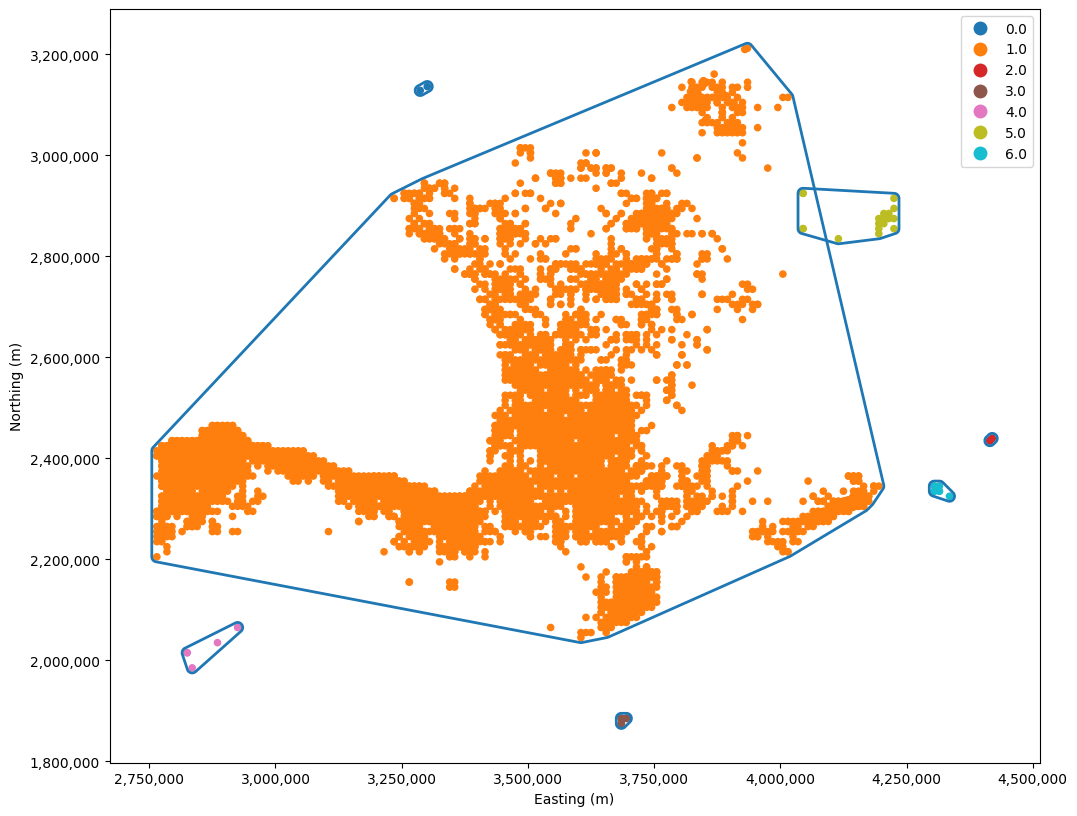

In [ ]:
from matplotlib.ticker import StrMethodFormatter

ax = region_hull_gdf.boundary.plot(
    figsize=(12, 10),
    linewidth=2
)

all_points_3035.plot(
    ax=ax,
    column="region_cluster",
    categorical=True,
    markersize=20,
    legend=True
)
# axis
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

In [ ]:
# Keep clusters 1 and 5
region_hull_selected = region_hull_gdf[
    region_hull_gdf["region_cluster"].isin([1, 5])
].copy()

# Combine selected regions
study_region = region_hull_selected.geometry.union_all()   ### IMPORTANT

## Import land and ocean polygons

In [ ]:
#################################################################
## study area box

study_area_3035 = gpd.GeoDataFrame(
    geometry=[study_region.buffer(60_000)],
    crs=region_hull_gdf.crs
)

bbox = tuple(
    study_area_3035.to_crs(4326).total_bounds
)

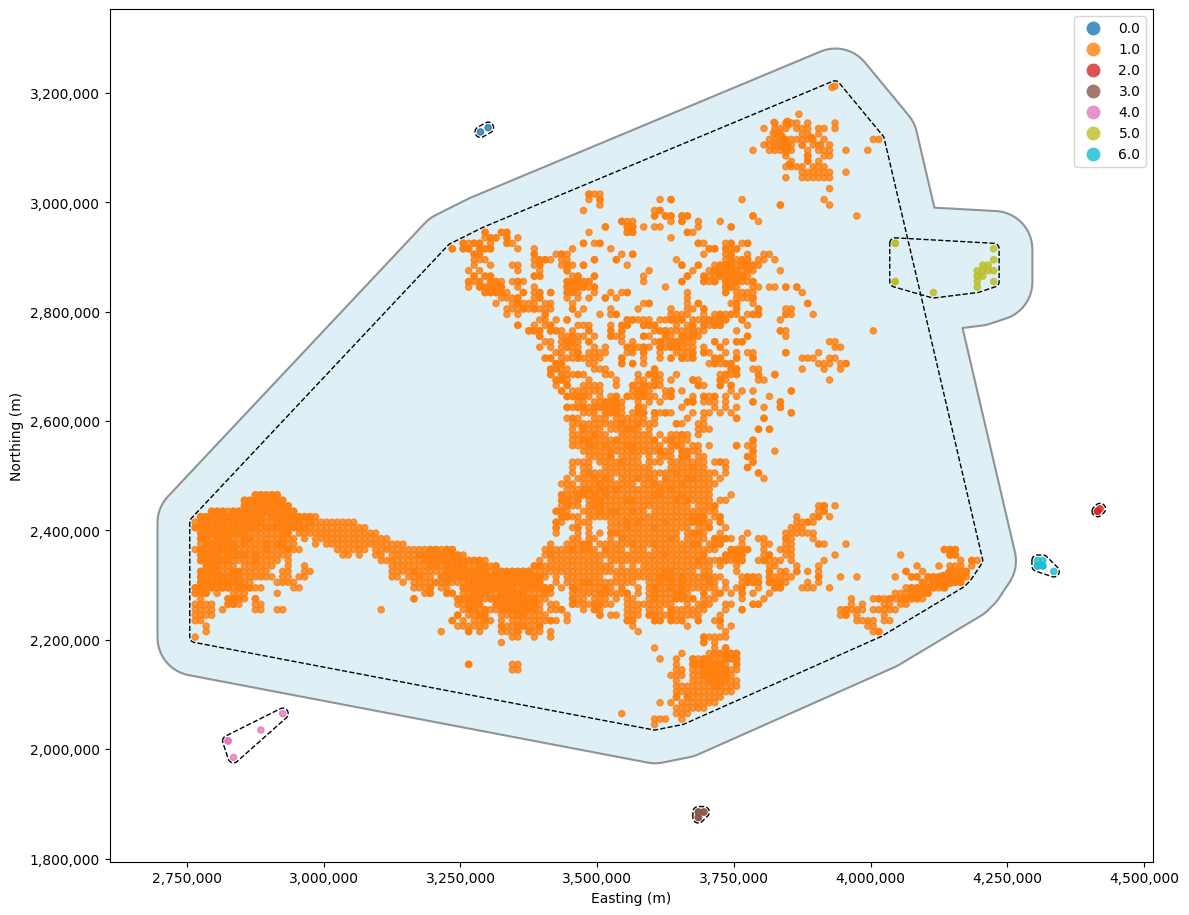

In [ ]:
from matplotlib.ticker import StrMethodFormatter
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))


study_area_3035.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="black",
    linewidth=1.5,
    alpha=0.4,
    zorder=1
)


region_hull_gdf.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.0,
    linestyle="--",
    zorder=2
)


all_points_3035.plot(
    ax=ax,
    column="region_cluster",
    categorical=True,
    cmap="tab10",
    markersize=20,
    alpha=0.8,
    legend=True,
    zorder=3
)

# Axis
ax.xaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)

ax.yaxis.set_major_formatter(
    StrMethodFormatter('{x:,.0f}')
)

ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")

ax.set_aspect("equal")
ax.grid(False)

plt.tight_layout()
plt.show()

####################INSERT A PLOT ############################

In [ ]:
land = gpd.read_file("/content/drive/MyDrive/MSC_PROJECT_YJ/data/land-polygons-split-4326/land_polygons.shp", bbox = bbox)


water = gpd.read_file("/content/drive/MyDrive/MSC_PROJECT_YJ/data/water-polygons-split-4326/water_polygons.shp", bbox = bbox)

### Plot layers and occurrence records



In [ ]:
#################################
### study box has been created

# study_area_3035 = gpd.GeoDataFrame(
#     geometry=region_hulls.buffer(150000),
#     crs=region_hulls.crs
# )
#######################################

In [ ]:
print(gdf_year1_3035.columns)
print(gdf_year2_3035.columns)
print(region_hull_gdf.columns)
print(regions.columns)

Index(['ObservationId', 'SpeciesId', 'SpeciesName', 'CountryId', 'WKT',
       'Centroid', 'Year', 'DataPartnerName', 'Reference', 'ReferenceUrl',
       'GeoJSON.type', 'GeoJSON.coordinates', 'Longitude', 'Latitude',
       'geometry'],
      dtype='object')
Index(['ObservationId', 'SpeciesId', 'SpeciesName', 'CountryId', 'WKT',
       'Centroid', 'Year', 'DataPartnerName', 'Reference', 'ReferenceUrl',
       'GeoJSON.type', 'GeoJSON.coordinates', 'Longitude', 'Latitude',
       'geometry'],
      dtype='object')
Index(['region_cluster', 'geometry'], dtype='object')
Index(['ObservationId', 'SpeciesId', 'SpeciesName', 'CountryId', 'WKT',
       'Centroid', 'Year', 'DataPartnerName', 'Reference', 'ReferenceUrl',
       'GeoJSON.type', 'GeoJSON.coordinates', 'Longitude', 'Latitude',
       'geometry', 'region_cluster'],
      dtype='object')


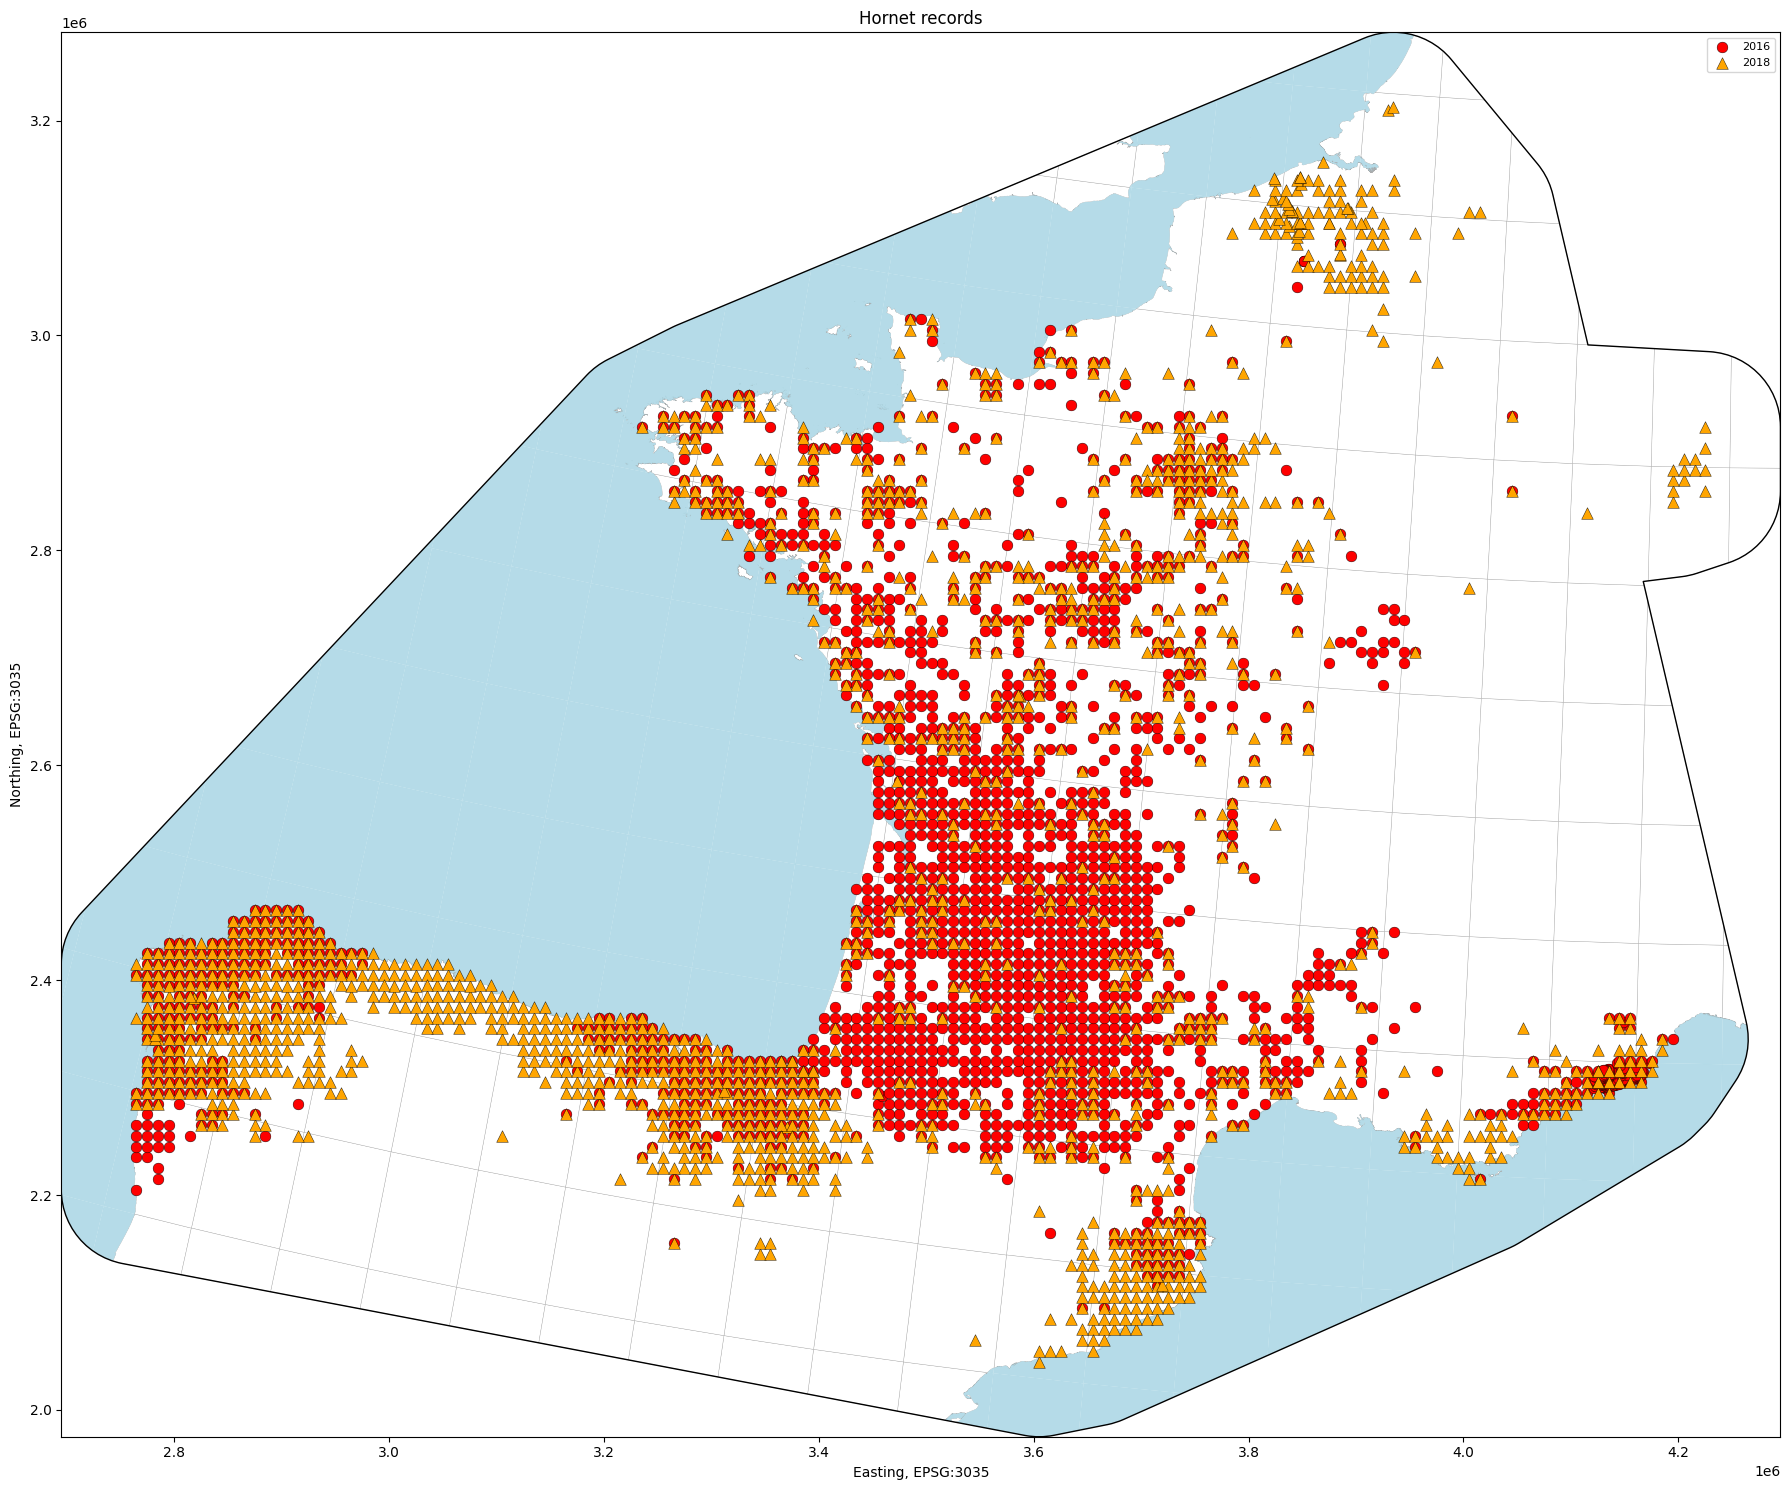

In [ ]:
land_3035 = land.to_crs(3035)
water_3035 = water.to_crs(3035)

water_3035["geometry"] = water_3035.geometry.make_valid()

water_3035 = water_3035[
    water_3035.geometry.notna()
    & ~water_3035.geometry.is_empty
].copy()

land_clip = gpd.clip(
    land_3035,
    study_area_3035
)

water_clip = gpd.clip(
    water_3035,
    study_area_3035
)

study_xmin, study_ymin, study_xmax, study_ymax = (
    study_area_3035.total_bounds
)

#  clusters 1 and 5
gdf_year1_selected = gpd.clip(
    gdf_year1_3035,
    study_area_3035
)

gdf_year2_selected = gpd.clip(
    gdf_year2_3035,
    study_area_3035
)


fig, ax = plt.subplots(figsize=(20, 15))

land_clip.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgrey",
    linewidth=0.3,
    zorder=1
)

water_clip.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.9,
    zorder=2
)

gdf_year1_selected.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    markersize=60,
    marker="o",
    label=str(year1),
    zorder=3
)

gdf_year2_selected.plot(
    ax=ax,
    color="orange",
    edgecolor="black",
    linewidth=0.3,
    markersize=70,
    marker="^",
    label=str(year2),
    zorder=4
)

study_area_3035.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1,
    zorder=5
)

ax.set_xlim(study_xmin, study_xmax)
ax.set_ylim(study_ymin, study_ymax)

ax.set_aspect("equal")
ax.grid(False)

ax.set_title("Hornet records")
ax.set_xlabel("Easting, EPSG:3035")
ax.set_ylabel("Northing, EPSG:3035")

ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()



---



## Create 20km grid

In [ ]:
#########################################################
### study area and grid parameters

cell_size = 20_000

x_shift = 6000
y_shift = 6500

study_xmin, study_ymin, study_xmax, study_ymax = (
    study_area_3035.total_bounds
)

#########################################################
## create grid

grid_xmin = study_xmin + x_shift
grid_xmax = study_xmax + x_shift
grid_ymin = study_ymin + y_shift
grid_ymax = study_ymax + y_shift

cols = np.arange(grid_xmin, grid_xmax + cell_size, cell_size)
rows = np.arange(grid_ymax, grid_ymin - cell_size, -cell_size)

grid_cells = []

for x in cols[:-1]:
    for y in rows[:-1]:
        grid_cells.append(
            box(x, y - cell_size, x + cell_size, y)
        )

grid3035 = gpd.GeoDataFrame(
    {"patch_id": range(len(grid_cells))},
    geometry=grid_cells,
    crs="EPSG:3035"
)

# keep grids intersecting the irregular study area
grid3035 = grid3035[
    grid3035.geometry.intersects(
        study_area_3035.geometry.union_all()
    )
].copy()

grid3035 = grid3035.reset_index(drop=True)

grid3035["patch_id"] = range(len(grid3035))

print("grid3035 rows:", len(grid3035))
print("grid3035 bounds:", grid3035.total_bounds)
print("study_area bounds:", study_area_3035.total_bounds)

grid3035 rows: 3666
grid3035 bounds: [2700998.38978598 1968583.11314773 4300998.38978598 3288583.11314773]
study_area bounds: [2694998.38978598 1975055.287902   4295000.2702695  3282083.11314773]


In [ ]:
cell_size = 20_000
tol = 100

def check_near_gridline(gdf, name):
    x = gdf.geometry.x
    y = gdf.geometry.y


    dx = np.minimum(
        np.mod(x - grid_xmin, cell_size),
        cell_size - np.mod(x - grid_xmin, cell_size)
    )

    dy = np.minimum(
        np.mod(y - grid_ymin, cell_size),
        cell_size - np.mod(y - grid_ymin, cell_size)
    )

    near = gdf[(dx < tol) | (dy < tol)].copy()

    print(f"{name}")
    print("Nearest vertical grid line:", dx.min(), "m")
    print("Nearest horizontal grid line:", dy.min(), "m")
    print(f"Points within {tol} m of any grid line:", len(near))

    return near

nearyear1 = check_near_gridline(gdf_year1_3035, "year1")
nearyear2 = check_near_gridline(gdf_year2_3035, "year2")

year1
Nearest vertical grid line: 119.48502371180803 m
Nearest horizontal grid line: 89.89749058196321 m
Points within 100 m of any grid line: 1
year2
Nearest vertical grid line: 435.346379423514 m
Nearest horizontal grid line: 232.04666471621022 m
Points within 100 m of any grid line: 0


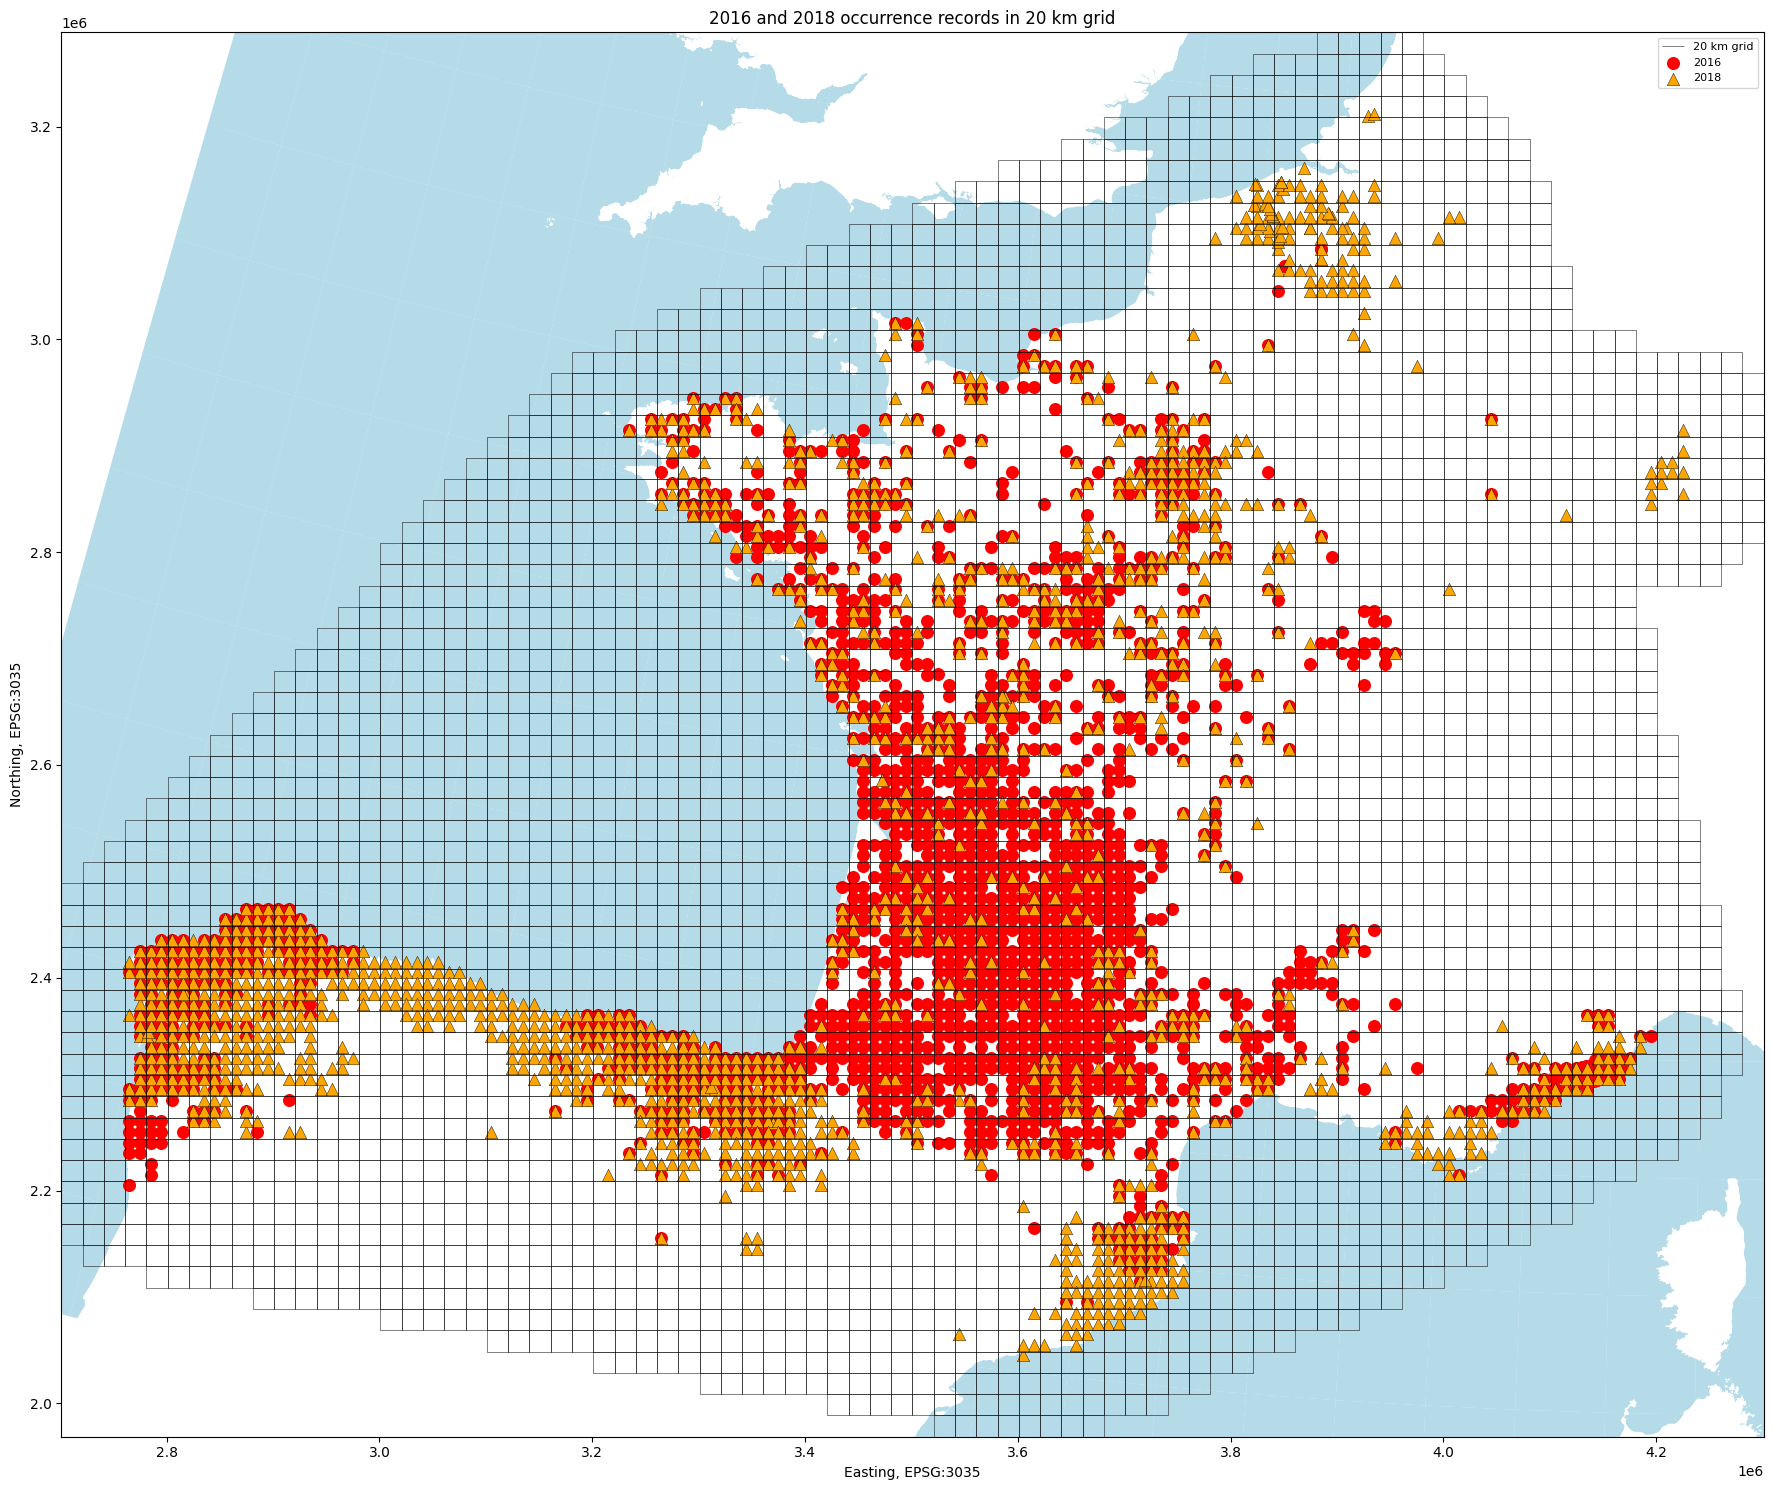

In [ ]:
### plot

# EPSG:3035
land_3035 = land.to_crs(3035)
water_3035 = water.to_crs(3035)

gdf_year1_3035 = gdf_year1.to_crs(3035)
gdf_year2_3035 = gdf_year2.to_crs(3035)

grid3035 = grid3035.to_crs(3035)

# study area based on the full grid extent
grid_xmin, grid_ymin, grid_xmax, grid_ymax = grid3035.total_bounds

study_box_3035 = gpd.GeoDataFrame( geometry=[box(grid_xmin, grid_ymin, grid_xmax, grid_ymax)], crs="EPSG:3035")

# clip land to the grid extent
land_clip = gpd.clip(
    land_3035,
    study_box_3035)

# ocean
water_clip = water_3035.cx[
    grid_xmin:grid_xmax,
    grid_ymin:grid_ymax].copy()

# grid
grid_plot = grid3035.copy()

fig, ax = plt.subplots(figsize=(20, 15))

water_clip.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.8,
    zorder=1
)

land_clip.plot(
    ax=ax,
    facecolor="white",
    edgecolor="darkgrey",
    alpha=0.5,
    linewidth=0.3,
    zorder=2
)

grid_plot.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.7,
    zorder=20,
    label="20 km grid"
)

gdf_year1_selected.plot(
    ax=ax,
    color="red",
    markersize=70,
    marker="o",
    label=str(year1),
    zorder=10
)

gdf_year2_selected.plot(
    ax=ax,
    color="orange",
    edgecolor="black",
    linewidth=0.3,
    markersize=80,
    marker="^",
    label=str(year2),
    zorder=11
)

ax.set_xlim(grid_xmin, grid_xmax)
ax.set_ylim(grid_ymin, grid_ymax)

ax.set_aspect("equal")
ax.grid(False)

ax.set_title(
    f"{year1} and {year2} occurrence records in 20 km grid"
)
ax.set_xlabel("Easting, EPSG:3035")
ax.set_ylabel("Northing, EPSG:3035")

ax.legend(
    loc="upper right",
    fontsize=8,
    frameon=True
)

plt.tight_layout()
plt.show()

## Remove non-study patches

In [ ]:
# Cell area
grid3035["cell_area"] = grid3035.geometry.area

# Grid overlay with land polygons
grid_land3035 = gpd.overlay(grid3035[["patch_id", "geometry"]], land_3035[["geometry"]], how="intersection", keep_geom_type=True)

# land area in each patch
grid_land3035["land_area"] = grid_land3035.geometry.area

land_area = (grid_land3035.groupby("patch_id", as_index=False)["land_area"].sum())

# Merge back to original grid
grid_land3035 = grid3035.merge(land_area, on="patch_id", how="left")

# define ocean patches
grid_land3035["land_area"] = (grid_land3035["land_area"].fillna(0))

# land proportion
grid_land3035["land_prop"] = (grid_land3035["land_area"] / grid_land3035["cell_area"])

# remove ocean patches
grid_land3035 = grid_land3035[grid_land3035["land_prop"] > 0].copy()


In [ ]:
print("Original grid:", len(grid3035))
print("Land patches:", len(grid_land3035))
print(
    "Removed ocean patches:",
    len(grid3035) - len(grid_land3035)
)
print(grid_land3035["land_prop"].describe())

Original grid: 3666
Land patches: 2644
Removed ocean patches: 1022
count    2644.000000
mean        0.936542
std         0.215181
min         0.000006
25%         1.000000
50%         1.000000
75%         1.005573
max         1.011475
Name: land_prop, dtype: float64


## Label patch

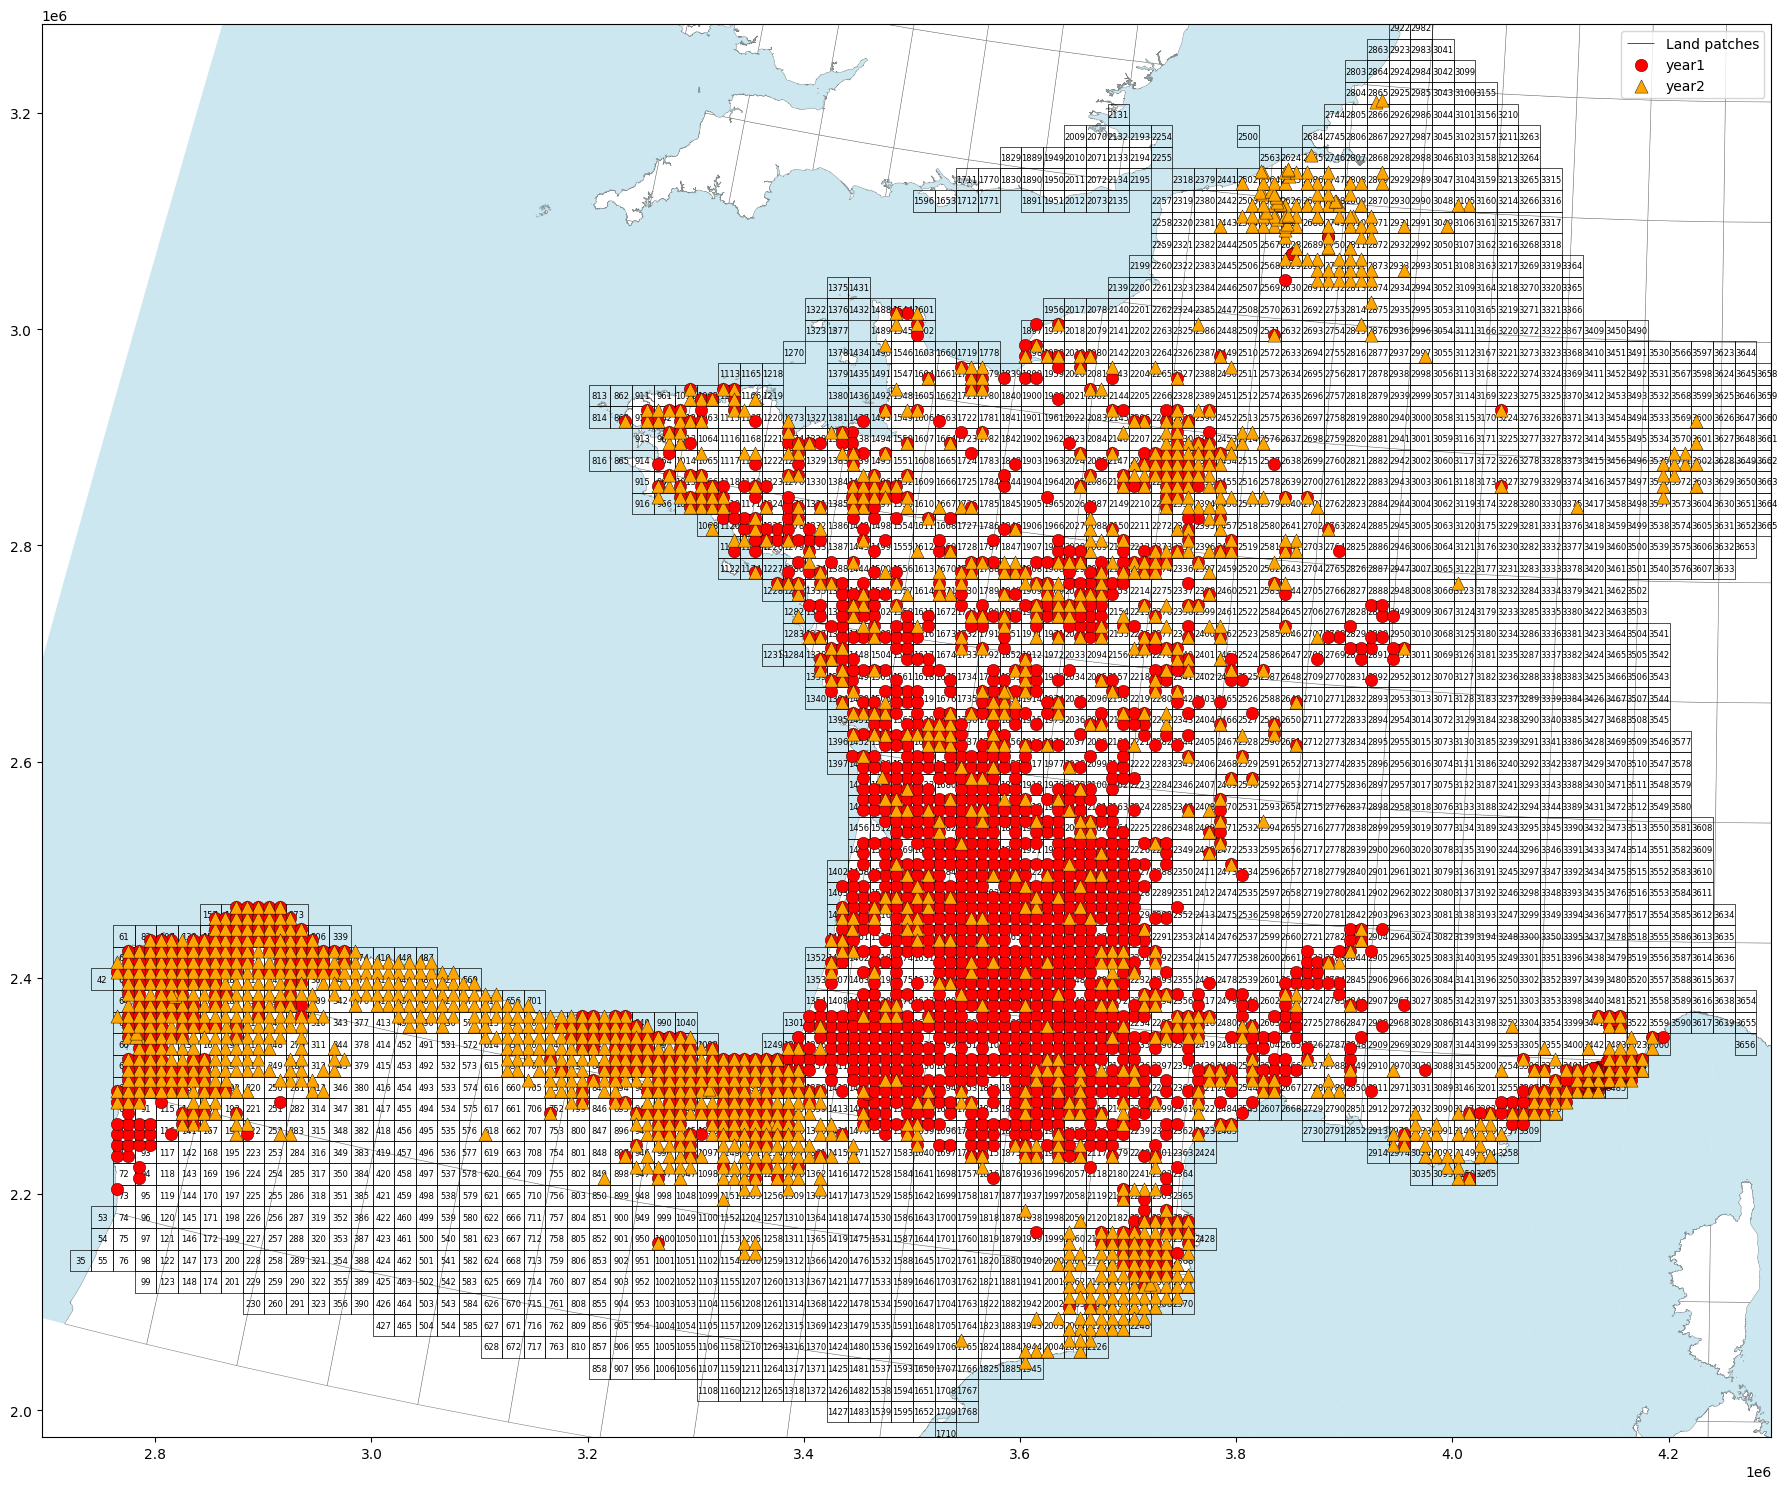

In [ ]:
grid_land_plot = grid_land3035.copy()

fig, ax = plt.subplots(figsize=(20, 15))

land_clip.plot(
    ax=ax,
    facecolor="white",
    edgecolor="grey",
    linewidth=0.4,
    zorder=1
)

water_clip.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.6,
    zorder=2
)


grid_land_plot.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.6,
    alpha=0.8,
    zorder=5,
    label="Land patches"
)

for _, row in grid_land_plot.iterrows():
    c = row.geometry.centroid

    ax.text(
        c.x,
        c.y,
        str(row["patch_id"]),
        fontsize=6,
        color="black",
        ha="center",
        va="center",
        zorder=20
    )

gdf_year1_selected.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    markersize=80,
    marker="o",
    label="year1",
    zorder=30
)

gdf_year2_selected.plot(
    ax=ax,
    color="orange",
    edgecolor="black",
    linewidth=0.3,
    markersize=90,
    marker="^",
    label="year2",
    zorder=31
)

xmin, ymin, xmax, ymax = study_area_3035.total_bounds

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
ax.grid(False)


ax.legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

In [ ]:
study_area_3035.to_crs(4326).total_bounds

array([-10.1366954 ,  40.50952106,   9.64614794,  52.51402764])

# Import country boundaries

In [ ]:
countries_3035 = gpd.read_file(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/data/country_boundary/CNTR_RG_10M_2016_3035.gpkg"
)

print(countries_3035.crs)
print(countries_3035.columns)
print(countries_3035.head())

EPSG:3035
Index(['CNTR_ID', 'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE',
       'SVRG_UN', 'CAPT', 'STAT_CODE', 'EU_STAT', 'NAME_GERM', 'geometry'],
      dtype='object')
  CNTR_ID                 CNTR_NAME             NAME_ENGL  \
0      AD                   Andorra               Andorra   
1      AE  الإمارات العربية المتحدة  United Arab Emirates   
2      AF       افغانستان-افغانستان           Afghanistan   
3      AG       Antigua and Barbuda   Antigua and Barbuda   
4      AI                  Anguilla              Anguilla   

             NAME_FREN ISO3_CODE                          SVRG_UN  \
0              Andorre       AND                  UN Member State   
1  Émirats arabes unis       ARE                  UN Member State   
2          Afghanistan       AFG                  UN Member State   
3   Antigua-et-Barbuda       ATG                  UN Member State   
4             Anguilla       AIA  UK Non-Self-Governing Territory   

               CAPT STAT_CODE EU_STAT   

In [ ]:
countries_clip = gpd.clip(countries_3035, study_area_3035)

print(countries_clip[["CNTR_ID", "NAME_ENGL"]].drop_duplicates())

    CNTR_ID       NAME_ENGL
65       FR          France
109      IT           Italy
0        AD         Andorra
122      MC          Monaco
77       ES           Spain
171      PT        Portugal
131      JE          Jersey
14       CH     Switzerland
118      LU      Luxembourg
23       BE         Belgium
90       GG        Guernsey
222      UK  United Kingdom
63       DE         Germany
169      NL     Netherlands


In [ ]:
# remove UK from country polygons
countries_3035 = countries_3035[
    countries_3035["CNTR_ID"] != "UK"
].copy()


grid_land3035 = gpd.sjoin(
    grid_land3035,
    countries_3035[["geometry"]],
    how="inner",
    predicate="intersects"
).drop(columns="index_right")

grid_land3035 = grid_land3035.drop_duplicates(
    subset="patch_id"
).copy()

# remove some patches
remove_patch_ids = [35, 42, 53, 813, 814, 816, 990,
                    1040, 1165, 1218, 1231, 1270, 1283,
                    1322, 1323, 1375, 1376, 1377, 1378, 1379, 1380, 1381,
                    1431, 1432, 1434, 1435, 1436, 1718, 1719, 1710,
                    2318, 2500, 2803, 2863, 2730, 3035]

grid_land3035 = grid_land3035[
    ~grid_land3035["patch_id"].isin(remove_patch_ids)
].copy()

In [ ]:
grid_land3035 = grid_land3035.reset_index(drop=True)
grid_land3035["patch_id"] = np.arange(len(grid_land3035))

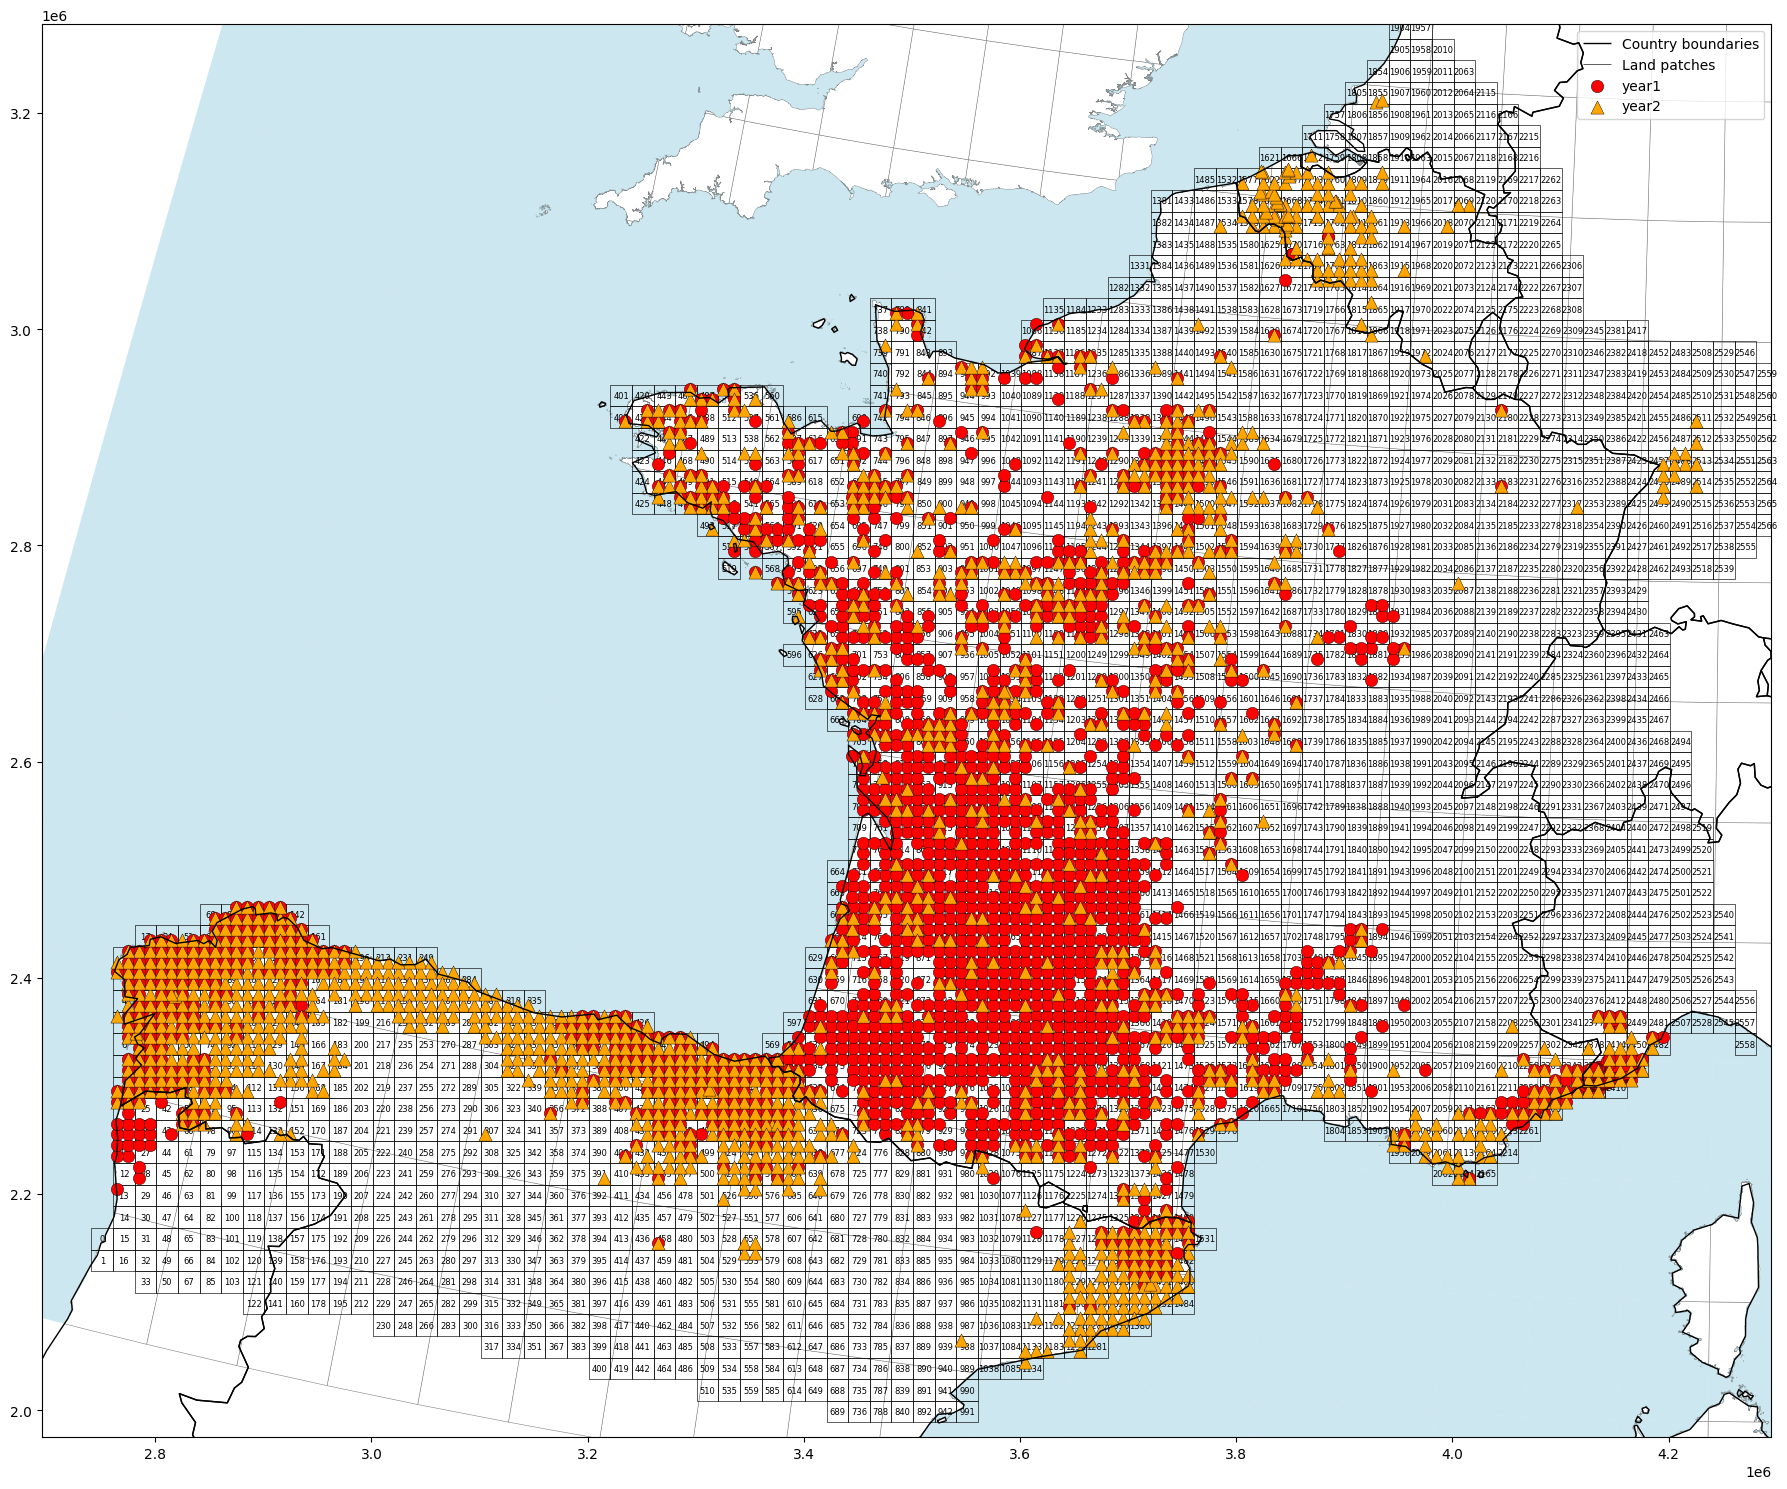

In [ ]:
grid_land_plot = grid_land3035.copy()

fig, ax = plt.subplots(figsize=(20, 15))

land_clip.plot(
    ax=ax,
    facecolor="white",
    edgecolor="grey",
    linewidth=0.4,
    zorder=1
)

water_clip.plot(
    ax=ax,
    facecolor="lightblue",
    edgecolor="none",
    alpha=0.6,
    zorder=2
)

countries_3035.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.0,
    zorder=40,
    label="Country boundaries"
)



grid_land_plot.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=0.55,
    alpha=0.8,
    zorder=5,
    label="Land patches"
)

for _, row in grid_land_plot.iterrows():
    c = row.geometry.centroid

    ax.text(
        c.x,
        c.y,
        str(row["patch_id"]),
        fontsize=6,
        color="black",
        ha="center",
        va="center",
        zorder=20
    )

gdf_year1_selected.plot(
    ax=ax,
    color="red",
    edgecolor="black",
    linewidth=0.3,
    markersize=80,
    marker="o",
    label="year1",
    zorder=30
)

gdf_year2_selected.plot(
    ax=ax,
    color="orange",
    edgecolor="black",
    linewidth=0.3,
    markersize=90,
    marker="^",
    label="year2",
    zorder=31
)

xmin, ymin, xmax, ymax = study_area_3035.total_bounds

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ax.set_aspect("equal")
ax.grid(False)


ax.legend(loc="upper right", fontsize=10, frameon=True)

plt.tight_layout()
plt.show()

## Divide sub-area

In [ ]:
countries_3035.columns

Index(['CNTR_ID', 'CNTR_NAME', 'NAME_ENGL', 'NAME_FREN', 'ISO3_CODE',
       'SVRG_UN', 'CAPT', 'STAT_CODE', 'EU_STAT', 'NAME_GERM', 'geometry'],
      dtype='object')

In [ ]:
# countries boundary
france_boundary = countries_3035.loc[countries_3035["CNTR_ID"] == "FR",
    "geometry"].union_all()

spain_boundary = countries_3035.loc[countries_3035["CNTR_ID"] == "ES",
    "geometry"].union_all()

germany_boundary = countries_3035.loc[countries_3035["CNTR_ID"] == "DE",
    "geometry"].union_all()

belgium_boundary = countries_3035.loc[countries_3035["CNTR_ID"] == "BE",
    "geometry"].union_all()

portugal_boundary = countries_3035.loc[countries_3035["CNTR_ID"] == "PT",
    "geometry"].union_all()

italy_boundary = countries_3035.loc[countries_3035["CNTR_ID"] == "IT",
    "geometry"].union_all()

study_geom = study_area_3035.geometry.union_all()

## -----------------------------------------
france_plus_portugal = france_boundary.union(portugal_boundary)

# Region 1: France and Portugal
region1 = study_geom.intersection(france_plus_portugal)

# Region 2: Others
region2 = study_geom.difference(region1)


NOTE:

> The mathematical model developed in this study shows that human-mediated dispersal of the invasive yellow-legged hornet may not be the only factor explaining the hornet's rapid range expansion.



Robinet, C., Suppo, C. and Darrouzet, E. (2017), Rapid spread of the invasive yellow-legged hornet in France: the role of human-mediated dispersal and the effects of control measures. J Appl Ecol, 54: 205-215. https://doi.org/10.1111/1365-2664.12724


## Re-label patches

In [ ]:
# grid_region1: France + Portugal
# grid_region2: Spain


In [ ]:
## Retain the global labels and set regional labels

# Region 1 patches
grid_region1 = grid_land3035.loc[
    grid_land3035.geometry.intersects(region1)
].copy()

grid_region1 = (
    grid_region1
    .rename(columns={"patch_id": "global_patch_id"})
    .reset_index(drop=True)
)

grid_region1["patch_id"] = np.arange(len(grid_region1))


# Region 2 patches = all remaining patches
grid_region2 = grid_land3035.loc[
    ~grid_land3035["patch_id"].isin(grid_region1["global_patch_id"])
].copy()

grid_region2 = (
    grid_region2
    .rename(columns={"patch_id": "global_patch_id"})
    .reset_index(drop=True)
)

grid_region2["patch_id"] = np.arange(len(grid_region2))


print("Region 1 patches:", len(grid_region1))
print(grid_region1[["global_patch_id", "patch_id"]].tail())

print("\nRegion 2 patches:", len(grid_region2))
print(grid_region2[["global_patch_id", "patch_id"]].tail())

Region 1 patches: 1570
      global_patch_id  patch_id
1565             2423      1565
1566             2424      1566
1567             2425      1567
1568             2457      1568
1569             2458      1569

Region 2 patches: 997
     global_patch_id  patch_id
992             2562       992
993             2563       993
994             2564       994
995             2565       995
996             2566       996


In [ ]:
print(grid_region1.columns)
print(grid_region2.columns)


Index(['global_patch_id', 'geometry', 'cell_area', 'land_area', 'land_prop',
       'patch_id'],
      dtype='object')
Index(['global_patch_id', 'geometry', 'cell_area', 'land_area', 'land_prop',
       'patch_id'],
      dtype='object')


### Count records--> Assign records to patches --> Count occupied patches

In [ ]:
# Global records
gdf_year1_global = gdf_year1_3035.copy()
gdf_year2_global = gdf_year2_3035.copy()

#---------------------------------------
# Regional records

# Region 1
gdf_year1_region1 = gdf_year1_3035[gdf_year1_3035.geometry.intersects(region1)
].copy()

gdf_year2_region1 = gdf_year2_3035[gdf_year2_3035.geometry.intersects(region1)
].copy()

#==============
# Region 2
gdf_year1_region2 = gdf_year1_3035[gdf_year1_3035.geometry.intersects(region2)
].copy()

gdf_year2_region2 = gdf_year2_3035[gdf_year2_3035.geometry.intersects(region2)
].copy()


print("Global, Year 1:", len(gdf_year1_global))
print("Global, Year 2:", len(gdf_year2_global))
print("Region 1, Year 1:", len(gdf_year1_region1))
print("Region 1, Year 2:", len(gdf_year2_region1))
print("Region 2, Year 1:", len(gdf_year1_region2))
print("Region 2, Year 2:", len(gdf_year2_region2))


Global, Year 1: 2273
Global, Year 2: 1720
Region 1, Year 1: 1638
Region 1, Year 2: 723
Region 2, Year 1: 626
Region 2, Year 2: 983


## Assign record to patch

In [ ]:
## Assign global records to global patches

gdf_year1_3035 = gpd.sjoin(
    gdf_year1_3035.drop(
        columns=["patch_id", "index_right"],
        errors="ignore"),
    grid_land3035[["patch_id", "geometry"]],
    how="left",
    predicate="intersects"
)

gdf_year2_3035 = gpd.sjoin(
    gdf_year2_3035.drop(
        columns=["patch_id", "index_right"],
        errors="ignore"
    ),
    grid_land3035[["patch_id", "geometry"]],
    how="left",
    predicate="intersects"
)

gdf_year1_3035 = gdf_year1_3035.dropna(subset=["patch_id"]).copy()

gdf_year2_3035 = gdf_year2_3035.dropna(subset=["patch_id"]).copy()

gdf_year1_3035["patch_id"] = (gdf_year1_3035["patch_id"].astype(int))

gdf_year2_3035["patch_id"] = (gdf_year2_3035["patch_id"].astype(int))


print("Global Year 1 unassigned:", gdf_year1_3035["patch_id"].isna().sum())
print("Global Year 2 unassigned:", gdf_year2_3035["patch_id"].isna().sum())


##-----------------------------------------------------------------------

## Assign records to Region 1 patches

gdf_year1_region1 = gpd.sjoin(
    gdf_year1_region1.drop(columns=["patch_id", "global_patch_id", "index_right"], errors="ignore"),
    grid_region1[["global_patch_id", "patch_id", "geometry"]],
    how="left",
    predicate="intersects"
)

gdf_year2_region1 = gpd.sjoin(
    gdf_year2_region1.drop(columns=["patch_id", "global_patch_id", "index_right"], errors="ignore"),
    grid_region1[["global_patch_id", "patch_id", "geometry"]],
    how="left",
    predicate="intersects"
)


## Assign records to Region 2 patches

gdf_year1_region2 = gpd.sjoin(
    gdf_year1_region2.drop(columns=["patch_id", "global_patch_id", "index_right"], errors="ignore"),
    grid_region2[["global_patch_id", "patch_id", "geometry"]],
    how="left",
    predicate="intersects"
)

gdf_year2_region2 = gpd.sjoin(
    gdf_year2_region2.drop(
        columns=["patch_id", "global_patch_id", "index_right"],
        errors="ignore"),
    grid_region2[
        ["global_patch_id", "patch_id", "geometry"]],
    how="left",
    predicate="intersects"
)




print("Region 1 Year 1 unassigned:",
      gdf_year1_region1["patch_id"].isna().sum())

print("Region 1 Year 2 unassigned:",
      gdf_year2_region1["patch_id"].isna().sum())

print("Region 2 Year 1 unassigned:",
      gdf_year1_region2["patch_id"].isna().sum())





for regional_gdf in [
    gdf_year1_region1,
    gdf_year2_region1,
    gdf_year1_region2,
    gdf_year2_region2,
]:
    regional_gdf.dropna(subset=["patch_id"], inplace=True)

    regional_gdf["patch_id"] = (regional_gdf["patch_id"].astype(int))

    regional_gdf["global_patch_id"] = (regional_gdf["global_patch_id"].astype(int))

print(grid_region1[["global_patch_id", "patch_id"]].tail(10))
print(grid_region2[["global_patch_id", "patch_id"]].tail(10))


same = (grid_region2["global_patch_id"] == grid_region2["patch_id"]).sum()

print(same)
print(len(grid_region2))



Global Year 1 unassigned: 0
Global Year 2 unassigned: 0
Region 1 Year 1 unassigned: 0
Region 1 Year 2 unassigned: 0
Region 2 Year 1 unassigned: 193
      global_patch_id  patch_id
1560             2389      1560
1561             2390      1561
1562             2391      1562
1563             2392      1563
1564             2393      1564
1565             2423      1565
1566             2424      1566
1567             2425      1567
1568             2457      1568
1569             2458      1569
     global_patch_id  patch_id
987             2557       987
988             2558       988
989             2559       989
990             2560       990
991             2561       991
992             2562       992
993             2563       993
994             2564       994
995             2565       995
996             2566       996
0
997


In [ ]:
%whos

Variable               Type            Data/Info
------------------------------------------------
DBSCAN                 type            <class 'sklearn.cluster._dbscan.DBSCAN'>
StrMethodFormatter     type            <class 'matplotlib.ticker.StrMethodFormatter'>
all_points_3035        GeoDataFrame                             <...>n[3993 rows x 16 columns]
ax                     Axes            Axes(0.067585,0.0379259;0.86483x0.941963)
bbox                   tuple           n=4
belgium_boundary       Polygon         POLYGON ((3962089.0626999<...>56060.2556 3160630.5514))
box                    function        <function box at 0x7c655c238040>
c                      Point           POINT (4290998.389785981 2818583.1131477314)
cell_size              int             20000
check_near_gridline    function        <function check_near_gridline at 0x7c65423afb00>
clustering             DBSCAN          DBSCAN(eps=85000, min_samples=1)
cols                   ndarray         82: 82 elems, type `fl



---



#PART TWO -- Patch attributes



## Calculate the state of patch $i$ occupancy $O_i$

In [ ]:
## Global ##

occyear1_ids = (gdf_year1_3035["patch_id"].dropna().astype(int).unique())

occyear2_ids = (gdf_year2_3035["patch_id"].dropna().astype(int).unique())

# Global occupancy state
grid_land3035["occyear1"] = (grid_land3035["patch_id"].isin(occyear1_ids).astype(int))

grid_land3035["occyear2"] = (grid_land3035["patch_id"].isin(occyear2_ids).astype(int))

print("Global year1 occupied patches:", grid_land3035["occyear1"].sum())

print("Global year2 occupied patches:",grid_land3035["occyear2"].sum())

#====================================================================
## Region 1 ##
occyear1_ids = gdf_year1_region1["patch_id"].dropna().astype(int).unique()
occyear2_ids = gdf_year2_region1["patch_id"].dropna().astype(int).unique()

# region 1 occupancy state
grid_region1["occyear1"] = (grid_region1["patch_id"].isin(occyear1_ids).astype(int))

grid_region1["occyear2"] = (grid_region1["patch_id"].isin(occyear2_ids).astype(int)
)

print("Region 1 year1 occupied patches:", grid_region1["occyear1"].sum())
print("Region 1 year2 occupied patches:", grid_region1["occyear2"].sum())

#====================================================================
## Region 2 ##
occyear1_ids = gdf_year1_region2["patch_id"].dropna().astype(int).unique()
occyear2_ids = gdf_year2_region2["patch_id"].dropna().astype(int).unique()

# region 2 occupancy state
grid_region2["occyear1"] = (grid_region2["patch_id"].isin(occyear1_ids).astype(int))

grid_region2["occyear2"] = (grid_region2["patch_id"].isin(occyear2_ids).astype(int))

print("Region 2 year1 occupied patches:", grid_region2["occyear1"].sum())
print("Region 2 year2 occupied patches:", grid_region2["occyear2"].sum())



Global year1 occupied patches: 866
Global year2 occupied patches: 794
Region 1 year1 occupied patches: 693
Region 1 year2 occupied patches: 472
Region 2 year1 occupied patches: 150
Region 2 year2 occupied patches: 282


## Calculate patch distance $D_{ij}$ --Shortest Path using Dijkstra's algorithm

In [ ]:
#-------------------------------------------------------------
##  Extract intersection between land and regional grid

grid_global_geom = (gpd.overlay(grid_land3035[["patch_id", "geometry"]],     land_3035[["geometry"]], how="intersection",keep_geom_type=True).dissolve(by="patch_id").reset_index())


print("Global patches:", len(grid_land3035))
print("Global patches with land geometry:", len(grid_global_geom))
#-----------------------------------------------------------
## 3 Extraxt centroid of the intersections


grid_global_geom["land_centroid"] = (grid_global_geom.geometry.centroid)

grid_land3035 = (grid_land3035.sort_values("patch_id").reset_index(drop=True))


#-------------------------------------------------------------
## 4 Join global land centroids back to global patches

grid_land3035 = grid_land3035.drop(columns="land_centroid", errors="ignore")

grid_land3035 = grid_land3035.merge(
    grid_global_geom[["patch_id", "land_centroid"]],
    on="patch_id",
    how="left"
)

grid_land3035 = (grid_land3035.sort_values("patch_id").reset_index(drop=True))



Global patches: 2567
Global patches with land geometry: 2567


In [ ]:
from scipy.sparse.csgraph import shortest_path

## 5  Map patch_id to matrix index

patch_id_to_idx_global = {}

for index, patch_id in enumerate(grid_land3035["patch_id"]):
    patch_id_to_idx_global[patch_id] = index

print("Global patch ID mapping:", list(patch_id_to_idx_global.items())[:5])



#-------------------------------------------------------------
## 6 Extract land-centroid coordinates



land_centroid_x_global = (grid_land3035["land_centroid"].x.to_numpy())

land_centroid_y_global = (grid_land3035["land_centroid"].y.to_numpy())



print("Global centroid x:")
print(land_centroid_x_global[:5])

print("Global centroid y:")
print(land_centroid_y_global[:5])


#-------------------------------------------------------------
## 7 Find adjacent patches



neighbors_global = gpd.sjoin(
    grid_global_geom[["patch_id", "geometry"]],
    grid_global_geom[["patch_id", "geometry"]],
    how="inner",
    predicate="touches",
    lsuffix="left",
    rsuffix="right"
)

neighbors_global = neighbors_global[
    neighbors_global["patch_id_left"] != neighbors_global["patch_id_right"]].copy()



print("Global neighbor records:", neighbors_global.shape)
print(neighbors_global[["patch_id_left", "patch_id_right"]].head())



#-------------------------------------------------------------
## 8 Create weighted adjacency matrices

from scipy.sparse import lil_matrix, csr_matrix




n_patches_global = len(grid_land3035)

adjacency_matrix_global = lil_matrix(
    (n_patches_global, n_patches_global), dtype=float)



print("Global adjacency matrix shape:", adjacency_matrix_global.shape)


#-------------------------------------------------------------
## 9 Add centroid distances to adjacency matrices

#global

for _, row in neighbors_global.iterrows():

    patch_id_i = row["patch_id_left"]
    patch_id_j = row["patch_id_right"]

    index_i = patch_id_to_idx_global[patch_id_i]
    index_j = patch_id_to_idx_global[patch_id_j]

    distance_km = np.sqrt(
        (land_centroid_x_global[index_i] - land_centroid_x_global[index_j]) ** 2+ (land_centroid_y_global[index_i] - land_centroid_y_global[index_j]) ** 2 ) / 1000

    adjacency_matrix_global[index_i, index_j] = distance_km
    adjacency_matrix_global[index_j, index_i] = distance_km



#-------------------------------------------------------------
## 10 Convert adjacency matrices to CSR format

adjacency_matrix_global = csr_matrix(adjacency_matrix_global)



print("Global non-zero directed edges:", adjacency_matrix_global.nnz)
print("Global undirected edges:", adjacency_matrix_global.nnz // 2)


#-------------------------------------------------------------
### 11 Calculate shortest-path distance matrices D_ij #####



#global
D_ij_global, predecessors_global = shortest_path(
    csgraph=adjacency_matrix_global,
    directed=False,
    method="D",
    return_predecessors=True
)


#-------------------------------------------------------------
## 12 Check global shortest-path distance matrix

print("Global:\n")
print("D_ij shape:", D_ij_global.shape)
print("Diagonal all zero:", np.allclose(np.diag(D_ij_global),0))
print("D_ij symmetric:", np.allclose(D_ij_global, D_ij_global.T))
print("Infinite distances:", np.isinf(D_ij_global).sum())

finite_D_global = D_ij_global[np.isfinite(D_ij_global)]
print("Maximum finite distance:", finite_D_global.max())

Global patch ID mapping: [(0, 0), (1, 1), (2, 2), (3, 3), (4, 4)]
Global centroid x:
[2755966.13414263 2751923.62112163 2774165.53848225 2773988.51177225
 2776348.14284173]
Global centroid y:
[2156580.00189305 2137986.6123049  2416511.72789277 2400306.67163078
 2379904.06557838]
Global neighbor records: (19462, 4)
   patch_id_left  patch_id_right
0              0               1
0              0              16
0              0              15
0              0              14
1              1              16
Global adjacency matrix shape: (2567, 2567)
Global non-zero directed edges: 19462
Global undirected edges: 9731
Global:

D_ij shape: (2567, 2567)
Diagonal all zero: True
D_ij symmetric: True
Infinite distances: 5132
Maximum finite distance: 1885.921167794143


## Calculate patch area $A_i$

In [ ]:
grid_land3035 = grid_land3035.drop(columns="A_i", errors="ignore")

In [ ]:
grid_land3035.columns.tolist()

['patch_id',
 'geometry',
 'cell_area',
 'land_area',
 'land_prop',
 'occyear1',
 'occyear2',
 'land_centroid']

In [ ]:
grid_land3035["land_area"].describe()

,land_area
count,2.567000e+03
mean,3.826815e+08
std,6.845065e+07
min,2.579563e+03
25%,4.000000e+08
50%,4.000000e+08
75%,4.022297e+08
max,4.045901e+08


In [ ]:
# global area
grid_land3035["A_i"] = grid_land3035["land_area"] / 1_000_000
# grid_land3035["A_i"] = grid_land3035["A_i"].clip(upper=100)

print("Full study area")
print(grid_land3035["A_i"].describe())



Full study area
count    2567.000000
mean      382.681471
std        68.450646
min         0.002580
25%       400.000000
50%       400.000000
75%       402.229702
max       404.590078
Name: A_i, dtype: float64


In [ ]:
A_i_raw = grid_land3035["land_area"] / 1_000_000

print(A_i_raw.describe())
print("Patches above 100 km²:", (A_i_raw > 400).sum())
print(
    "Proportion above 100 km²:",
    (A_i_raw > 400).mean()
)

count    2567.000000
mean      382.681471
std        68.450646
min         0.002580
25%       400.000000
50%       400.000000
75%       402.229702
max       404.590078
Name: land_area, dtype: float64
Patches above 100 km²: 988
Proportion above 100 km²: 0.38488507985975845


## Add regional labels

In [ ]:
# Add regional labels to the global patch table
#
# 0 = other global patches
# 1 = Region 1
# 2 = Region 2


grid_land3035 = (grid_land3035.sort_values("patch_id").reset_index(drop=True))

region1_global_ids = set(grid_region1["global_patch_id"].astype(int))

region2_global_ids = set(grid_region2["global_patch_id"].astype(int))


# Check that Region 1 and Region 2 do not overlap
overlap_ids = region1_global_ids.intersection(region2_global_ids)


print("Overlapping patch IDs:", len(overlap_ids))

assert len(overlap_ids) == 0


# Assign labels
grid_land3035["region"] = 0

grid_land3035.loc[grid_land3035["patch_id"]
                  .isin(region1_global_ids), "region"] = 1
grid_land3035.loc[grid_land3035["patch_id"]
                  .isin(region2_global_ids), "region"] = 2


print(grid_land3035["region"].value_counts().sort_index())
print(grid_land3035.columns)

Overlapping patch IDs: 0
region
1    1570
2     997
Name: count, dtype: int64
Index(['patch_id', 'geometry', 'cell_area', 'land_area', 'land_prop',
       'occyear1', 'occyear2', 'land_centroid', 'A_i', 'region'],
      dtype='object')




---
# Add country id


In [ ]:
grid_land3035.head()

,patch_id,geometry,cell_area,land_area,land_prop,occyear1,occyear2,land_centroid,A_i,region
0,0,"POLYGON ((2760998.39 2148583.113, 2760998.39 2...",400000000.0,1.796594e+08,0.449148,0,0,POINT (2755966.134 2156580.002),179.659369,1
1,1,"POLYGON ((2760998.39 2128583.113, 2760998.39 2...",400000000.0,3.588828e+08,0.897207,0,0,POINT (2751923.621 2137986.612),358.882792,1
2,2,"POLYGON ((2780998.39 2408583.113, 2780998.39 2...",400000000.0,2.328088e+08,0.582022,1,1,POINT (2774165.538 2416511.728),232.808759,2
3,3,"POLYGON ((2780998.39 2388583.113, 2780998.39 2...",400000000.0,2.426348e+08,0.606587,1,1,POINT (2773988.512 2400306.672),242.634810,2
4,4,"POLYGON ((2780998.39 2368583.113, 2780998.39 2...",400000000.0,1.125199e+08,0.281300,1,1,POINT (2776348.143 2379904.066),112.519858,2


In [ ]:
countries_3035 = gpd.read_file(
    "/content/drive/MyDrive/MSC_PROJECT_YJ/data/country_boundary/CNTR_RG_10M_2016_3035.gpkg"
)

In [ ]:
country_patch = gpd.sjoin(
    grid_land3035[
        ["patch_id", "occyear1", "occyear2", "geometry"]
    ],
    countries_3035[
        ["CNTR_ID", "NAME_ENGL", "geometry"]
    ],
    how="inner",
    predicate="intersects"
).drop(columns="index_right")


country_patch = country_patch.drop_duplicates(
    subset=["patch_id", "CNTR_ID"]
)

In [ ]:
print(
    country_patch[
        ["patch_id", "CNTR_ID", "NAME_ENGL",
         "occyear1", "occyear2"]
    ].head(20)
)

print(country_patch["NAME_ENGL"].value_counts())

    patch_id CNTR_ID NAME_ENGL  occyear1  occyear2
0          0      PT  Portugal         0         0
1          1      PT  Portugal         0         0
2          2      ES     Spain         1         1
3          3      ES     Spain         1         1
4          4      ES     Spain         1         1
5          5      ES     Spain         1         1
6          6      ES     Spain         1         1
7          7      ES     Spain         1         1
8          8      ES     Spain         1         1
8          8      PT  Portugal         1         1
9          9      ES     Spain         1         1
9          9      PT  Portugal         1         1
10        10      PT  Portugal         1         0
11        11      PT  Portugal         1         0
12        12      PT  Portugal         0         0
13        13      PT  Portugal         1         0
14        14      PT  Portugal         0         0
15        15      PT  Portugal         0         0
16        16      PT  Portugal 

In [ ]:
country_summary = ( country_patch.groupby(["CNTR_ID", "NAME_ENGL"])
    .agg(total_patches=("patch_id", "count"),
        occupied_2016=("occyear1", "sum"),
        occupied_2018=("occyear2", "sum")
    )
    .reset_index()
)

country_summary["unoccupied_2016"] = (
    country_summary["total_patches"]
    - country_summary["occupied_2016"]
)

country_summary["unoccupied_2018"] = (
    country_summary["total_patches"]
    - country_summary["occupied_2018"]
)

print(country_summary.to_string(index=False))

CNTR_ID   NAME_ENGL  total_patches  occupied_2016  occupied_2018  unoccupied_2016  unoccupied_2018
     AD     Andorra              6              0              1                6                5
     BE     Belgium            103              2             42              101               61
     CH Switzerland             83              0              0               83               83
     DE     Germany            156              0              9              156              147
     ES       Spain            678            170            269              508              409
     FR      France           1482            699            499              783              983
     IT       Italy            120             10             14              110              106
     LU  Luxembourg             16              0              0               16               16
     MC      Monaco              1              1              1                0                0
     NL Ne

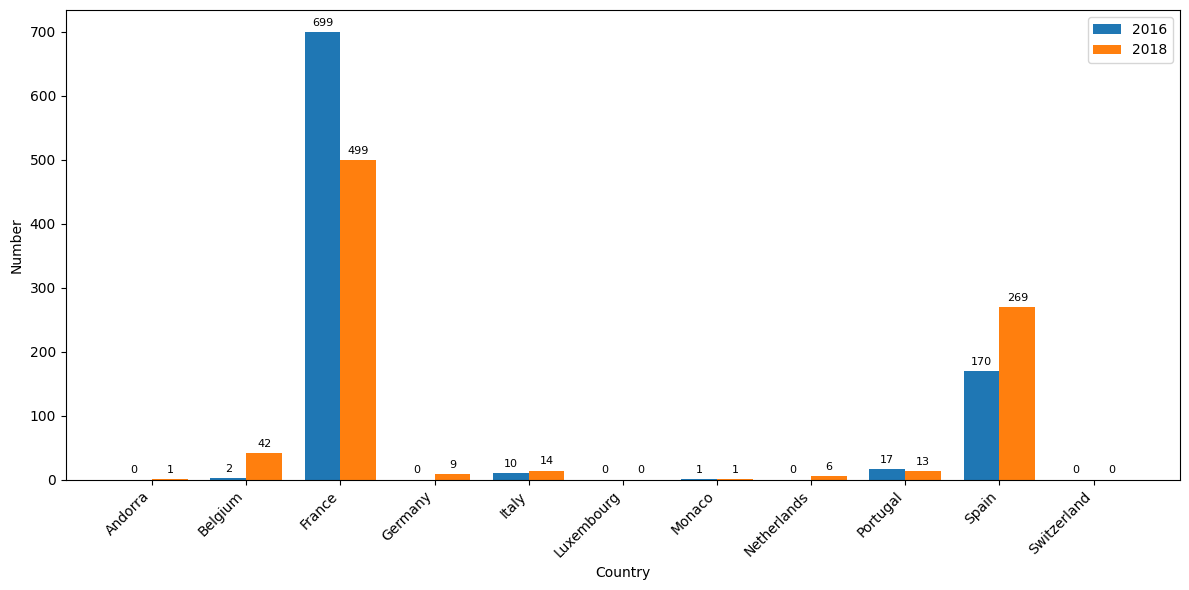

In [ ]:
plot_df = country_summary.sort_values("NAME_ENGL").copy()

x = np.arange(len(plot_df))
width = 0.38

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(
    x - width / 2,
    plot_df["occupied_2016"],
    width,
    label="2016"
)

bars2 = ax.bar(
    x + width / 2,
    plot_df["occupied_2018"],
    width,
    label="2018"
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_df["NAME_ENGL"],
    rotation=45,
    ha="right"
)

ax.set_ylabel("Number")
ax.set_xlabel("Country")
ax.legend()

ax.bar_label(bars1, padding=3, fontsize=8)
ax.bar_label(bars2, padding=3, fontsize=8)

plt.tight_layout()
plt.show()



---



# Save outputs

In [ ]:
grid_land3035.columns

Index(['patch_id', 'geometry', 'cell_area', 'land_area', 'land_prop',
       'occyear1', 'occyear2', 'land_centroid', 'A_i', 'region'],
      dtype='object')

In [ ]:
grid_land3035.head()

,patch_id,geometry,cell_area,land_area,land_prop,occyear1,occyear2,land_centroid,A_i,region
0,0,"POLYGON ((2760998.39 2148583.113, 2760998.39 2...",400000000.0,1.796594e+08,0.449148,0,0,POINT (2755966.134 2156580.002),179.659369,1
1,1,"POLYGON ((2760998.39 2128583.113, 2760998.39 2...",400000000.0,3.588828e+08,0.897207,0,0,POINT (2751923.621 2137986.612),358.882792,1
2,2,"POLYGON ((2780998.39 2408583.113, 2780998.39 2...",400000000.0,2.328088e+08,0.582022,1,1,POINT (2774165.538 2416511.728),232.808759,2
3,3,"POLYGON ((2780998.39 2388583.113, 2780998.39 2...",400000000.0,2.426348e+08,0.606587,1,1,POINT (2773988.512 2400306.672),242.634810,2
4,4,"POLYGON ((2780998.39 2368583.113, 2780998.39 2...",400000000.0,1.125199e+08,0.281300,1,1,POINT (2776348.143 2379904.066),112.519858,2


In [ ]:
# from pathlib import Path

# output_dir = Path("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/")

# output_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# output_dir.mkdir(parents=True, exist_ok=True)

# grid_land3035_save = (
#     grid_land3035[
#         [
#             "patch_id",
#             "cell_area",
#             "land_area",
#             "land_prop",
#             "A_i",
#             "occyear1",
#             "occyear2",
#             "region"
#         ]
#     ]
#     .sort_values("patch_id")
#     .reset_index(drop=True)
# )

# output_path = (output_dir / "hornet_patch_attributes_V5.csv")

# grid_land3035_save.to_csv(output_path, index=False)

# print("Saved:", output_path)
# print("Shape:", grid_land3035_save.shape)
# print("Columns:", grid_land3035_save.columns.tolist())

In [ ]:
# # Save patch attribute tables

# grid_land3035.to_csv(output_dir / "hornet_patch_attributes_global_V5.csv",    index=False)

# grid_region1.to_csv(output_dir / "hornet_patch_attributes_region1_V5.csv",    index=False)

# grid_region2.to_csv(output_dir / "hornet_patch_attributes_region2_V5.csv",     index=False)


In [ ]:
# # save shortest path distance
# np.save(output_dir / "hornet_D_shortest_global_V5.npy", D_ij_global)


# Save spatial layers

In [ ]:
## spatial

output_gpkg = ("/content/drive/MyDrive/MSC_PROJECT_YJ/outputs/"
    "hornet_plot_layers_FRPT.gpkg")


# 1. patches

hornet_patches = grid_land3035.copy()

# geometry column
main_geometry = hornet_patches.geometry.name


extra_geometry_cols = [
    col for col in hornet_patches.columns
    if str(hornet_patches[col].dtype) == "geometry"
    and col != main_geometry
]

print("Main geometry:", main_geometry)
print("Extra geometry columns:", extra_geometry_cols)

for col in extra_geometry_cols:
    hornet_patches[col] = hornet_patches[col].to_wkt()

hornet_patches.to_file(
    output_gpkg,
    layer="patches",
    driver="GPKG"
)


#---------------------------------------------
# 2. land background

land_plot = land_clip[
    ["geometry"]
].copy()

land_plot.to_file(
    output_gpkg,
    layer="land",
    driver="GPKG"
)


# 3. water background

water_plot = water_clip[
    ["geometry"]
].copy()

water_plot.to_file(
    output_gpkg,
    layer="water",
    driver="GPKG"
)


# 4. country boundaries

countries_plot = gpd.clip(
    countries_3035[
        ["CNTR_ID", "NAME_ENGL", "geometry"]
    ],
    study_area_3035
)

countries_plot.to_file(
    output_gpkg,
    layer="countries",
    driver="GPKG"
)


# 5. study-area extent/boundary

study_area_3035.to_file(
    output_gpkg,
    layer="study_area",
    driver="GPKG"
)

print("Saved:", output_gpkg)

Main geometry: geometry
Extra geometry columns: ['land_centroid']
Saved: /content/drive/MyDrive/MSC_PROJECT_YJ/outputs/hornet_plot_layers_FRPT.gpkg
